# Portfolios from Predictions

Sort stocks each month by the **percentile rank of `prediction`**, form `N_PORT` groups, build a long-short (top minus bottom), and plot performance.

**Alignment:** `target_w` is already next-month (t+1) return — the lead was built into the panel upstream. Sorting on `prediction` at `eom` and realizing `target_w` at the *same* `eom` is point-in-time correct, so **nothing is lagged here.** Lagging again would double-count and understate performance.

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [41]:
# ---- config ----------------------------------------------------------------
PRED_PATH = "LASSO_predictions.parquet"
N_PORT    = 10        # 10 = deciles, 5 = quintiles
EQUAL_WT  = True      # True: equal-weight; False + a 'me' column: value-weight
ANNUALIZE = 12        # monthly data

In [42]:
# ---- load ------------------------------------------------------------------
preds = pd.read_parquet(PRED_PATH)
preds["eom"] = pd.to_datetime(preds["eom"])
preds = preds.dropna(subset=["prediction", "target_w"])
print(f"{len(preds):,} predicted stock-months, "
      f"{preds['eom'].nunique()} months, "
      f"{preds['eom'].min():%Y-%m} to {preds['eom'].max():%Y-%m}")

1,937,791 predicted stock-months, 376 months, 1994-01 to 2025-04


In [43]:
# ---- assign portfolios: percentile rank of prediction WITHIN each month ----
# rank(pct=True) -> (0,1]; ceil(r * N_PORT) buckets into 1..N_PORT.
# method="first" breaks ties by order so bucket sizes stay balanced.
r = preds.groupby("eom")["prediction"].rank(pct=True, method="first")
preds["port"] = np.ceil(r * N_PORT).clip(1, N_PORT).astype(int)

In [44]:
# ---- monthly return of each portfolio --------------------------------------
# equal-weight = simple mean of target_w within (month, port).
# value-weight: set EQUAL_WT=False and include a 'me' (market-equity) column.
if EQUAL_WT or "me" not in preds.columns:
    port_ret = (preds.groupby(["eom", "port"])["target_w"]
                     .mean().unstack("port"))
else:
    def vw(g):
        return np.average(g["target_w"], weights=g["me"].to_numpy())
    port_ret = preds.groupby(["eom", "port"]).apply(vw).unstack("port")

port_ret.columns = [f"P{c}" for c in port_ret.columns]
port_ret["LS"] = port_ret[f"P{N_PORT}"] - port_ret["P1"]   # long top, short bottom

In [45]:
# ---- summary stats ---------------------------------------------------------
def stats(x):
    x = x.dropna()
    mu, sd = x.mean(), x.std()
    return pd.Series({
        "ann_return":  mu * ANNUALIZE,
        "ann_vol":     sd * np.sqrt(ANNUALIZE),
        "sharpe":      (mu / sd * np.sqrt(ANNUALIZE)) if sd > 0 else np.nan,
        "hit_rate":    (x > 0).mean(),
        "worst_month": x.min(),
    })

summary = port_ret.apply(stats).T
summary.round(4)

,ann_return,ann_vol,sharpe,hit_rate,worst_month
P1,-0.0213,0.1904,-0.1121,0.5213,-0.2459
P2,0.0285,0.1691,0.1685,0.5745,-0.2323
P3,0.0499,0.1556,0.3208,0.5878,-0.2101
P4,0.0569,0.1621,0.3514,0.5798,-0.2731
P5,0.0693,0.1674,0.4139,0.5957,-0.2678
P6,0.0844,0.1791,0.4714,0.5904,-0.2633
P7,0.1070,0.1911,0.5601,0.5984,-0.2717
P8,0.1215,0.2118,0.5738,0.6090,-0.2656
P9,0.1594,0.2313,0.6893,0.6090,-0.2436
P10,0.2238,0.2650,0.8444,0.6090,-0.2460


In [46]:
# ---- cumulative growth of $1 (compounded) ----------------------------------
cum = (1 + port_ret).cumprod()

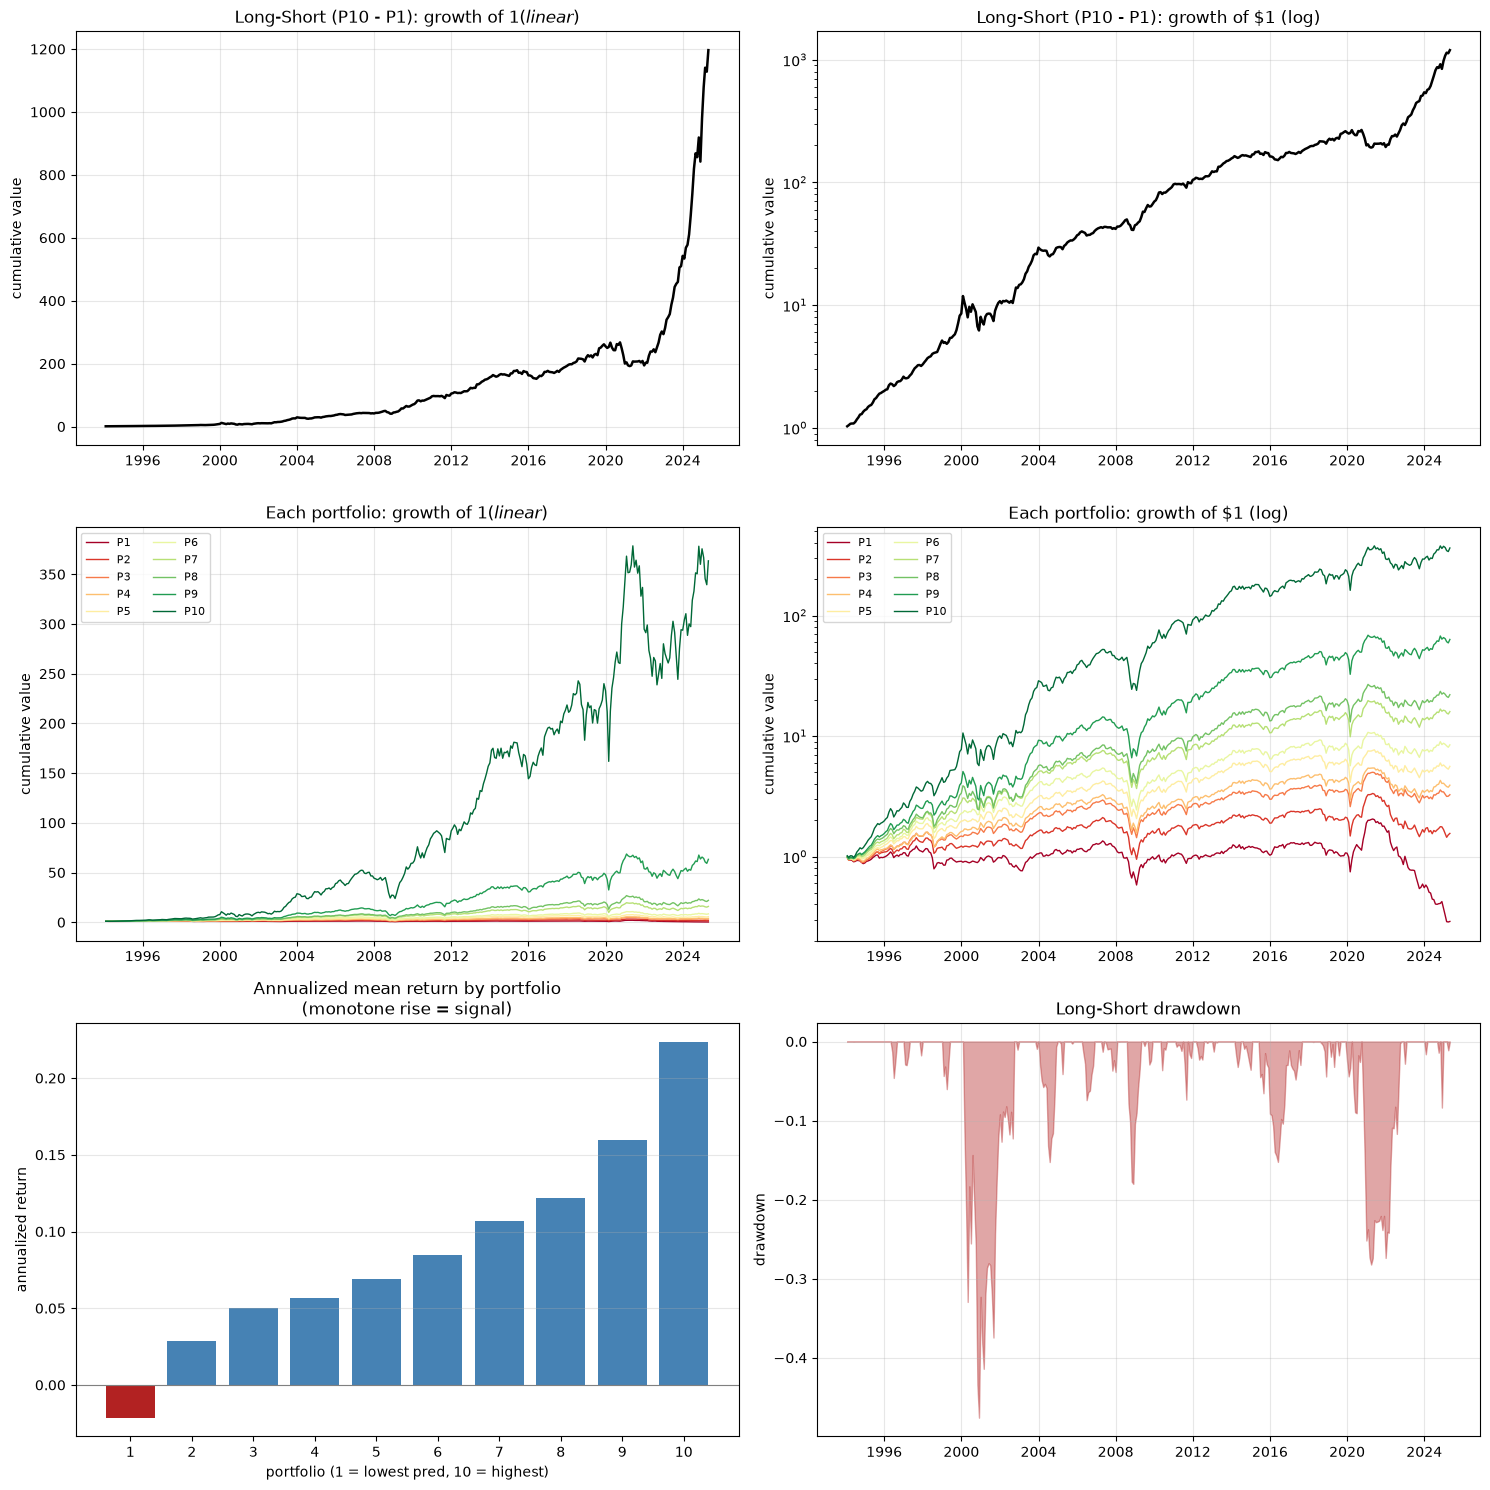

In [47]:
# ---- plots -----------------------------------------------------------------
# Two cumulative views each for LS and the deciles: linear ($ value as you'd
# actually read it) and log (so the early years aren't visually crushed by
# late compounding). 3 rows x 2 cols.
fig, axes = plt.subplots(3, 2, figsize=(15, 15))
cmap = plt.cm.RdYlGn(np.linspace(0, 1, N_PORT))

# row 1: long-short growth of $1 -- linear (left) and log (right)
for ax, logy in ((axes[0, 0], False), (axes[0, 1], True)):
    ax.plot(cum.index, cum["LS"], lw=1.8, color="black")
    if logy:
        ax.set_yscale("log")
    ax.set_title(f"Long-Short (P{N_PORT} - P1): growth of $1"
                 + (" (log)" if logy else " (linear $)"))
    ax.set_ylabel("cumulative value"); ax.grid(True, alpha=0.3)

# row 2: each portfolio's growth of $1 -- linear (left) and log (right)
for ax, logy in ((axes[1, 0], False), (axes[1, 1], True)):
    for i in range(1, N_PORT + 1):
        ax.plot(cum.index, cum[f"P{i}"], lw=1.0, color=cmap[i-1], label=f"P{i}")
    if logy:
        ax.set_yscale("log")
    ax.set_title("Each portfolio: growth of $1"
                 + (" (log)" if logy else " (linear $)"))
    ax.set_ylabel("cumulative value"); ax.grid(True, alpha=0.3)
    ax.legend(ncol=2, fontsize=8)

# row 3 left: mean annualized return by portfolio (monotonicity test)
ax = axes[2, 0]
means = port_ret[[f"P{i}" for i in range(1, N_PORT+1)]].mean() * ANNUALIZE
colors = ["firebrick" if v < 0 else "steelblue" for v in means]
ax.bar(range(1, N_PORT+1), means.values, color=colors)
ax.axhline(0, color="grey", lw=0.8)
ax.set_title("Annualized mean return by portfolio\n(monotone rise = signal)")
ax.set_xlabel(f"portfolio (1 = lowest pred, {N_PORT} = highest)")
ax.set_ylabel("annualized return")
ax.set_xticks(range(1, N_PORT+1)); ax.grid(True, alpha=0.3, axis="y")

# row 3 right: long-short drawdown
ax = axes[2, 1]
dd = cum["LS"] / cum["LS"].cummax() - 1
ax.fill_between(dd.index, dd.values, 0, color="firebrick", alpha=0.4)
ax.set_title("Long-Short drawdown")
ax.set_ylabel("drawdown"); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Is the spread real?
A line that goes up isn't proof of skill. The monthly `LS` series lets you test it — a *t*-stat on the mean, and (with factor data) a regression on market/size/value/momentum to see if there's alpha beyond known premia.

In [48]:
# quick significance check on the long-short mean
from scipy import stats as sps
ls = port_ret["LS"].dropna()
t, p = sps.ttest_1samp(ls, 0)
print(f"LS monthly mean {ls.mean():.4%} | t-stat {t:.2f} | p-value {p:.4g} "
      f"| n={len(ls)} months")

LS monthly mean 2.0428% | t-stat 7.31 | p-value 1.665e-12 | n=376 months


## Sub-period comparison: first half vs second half

The sample spans 1994–2025; the midpoint falls at 2009/2010, so **H1 = 1994–2009** and **H2 = 2010–2025**. This splits the *realized* long-short returns of the one strategy in two to check whether its return/risk profile held up across eras — it does **not** retrain the model per half.

A signal that's real but time-varying often shows a strong first half and a weaker second (factors decay as they get crowded); a signal that's an artifact often shows up in only one half. Consistent stats across both is the encouraging case.

In [49]:
# ---- split realized returns into two EQUAL halves by MONTH COUNT -----------
# equal month split: first N/2 months vs last N/2 months (differ by at most 1
# when the total is odd), regardless of calendar year. This makes H1 and H2
# equal-length samples rather than splitting on a year boundary.
port_ret = port_ret.sort_index()
n_months = len(port_ret)
mid = n_months // 2
h1 = port_ret.iloc[:mid]
h2 = port_ret.iloc[mid:]
print(f"{n_months} months -> H1 {len(h1)} months, H2 {len(h2)} months")
print(f"H1: {h1.index.min():%Y-%m} to {h1.index.max():%Y-%m}")
print(f"H2: {h2.index.min():%Y-%m} to {h2.index.max():%Y-%m}")

376 months -> H1 188 months, H2 188 months
H1: 1994-01 to 2009-08
H2: 2009-09 to 2025-04


In [50]:
# ---- side-by-side return/risk stats for the long-short ---------------------
def period_stats(x):
    x = x.dropna()
    mu, sd = x.mean(), x.std()
    dd = (1 + x).cumprod()
    max_dd = (dd / dd.cummax() - 1).min()
    from scipy import stats as sps
    t, p = sps.ttest_1samp(x, 0)
    return pd.Series({
        "months":      len(x),
        "ann_return":  mu * ANNUALIZE,
        "ann_vol":     sd * np.sqrt(ANNUALIZE),
        "sharpe":      mu / sd * np.sqrt(ANNUALIZE) if sd > 0 else np.nan,
        "hit_rate":    (x > 0).mean(),
        "max_drawdown": max_dd,
        "t_stat":      t,
        "p_value":     p,
    })

compare = pd.DataFrame({
    "H1 (" + str(h1.index.year.min()) + "-" + str(h1.index.year.max()) + ")": period_stats(h1["LS"]),
    "H2 (" + str(h2.index.year.min()) + "-" + str(h2.index.year.max()) + ")": period_stats(h2["LS"]),
    "Full": period_stats(port_ret["LS"]),
})
compare.round(4)

,H1 (1994-2009),H2 (2009-2025),Full
months,188.0000,188.0000,376.0000
ann_return,0.2939,0.1964,0.2451
ann_vol,0.2253,0.1399,0.1878
sharpe,1.3042,1.4043,1.3053
hit_rate,0.7287,0.6330,0.6809
max_drawdown,-0.4757,-0.2820,-0.4757
t_stat,5.1621,5.5583,7.3064
p_value,0.0000,0.0000,0.0000


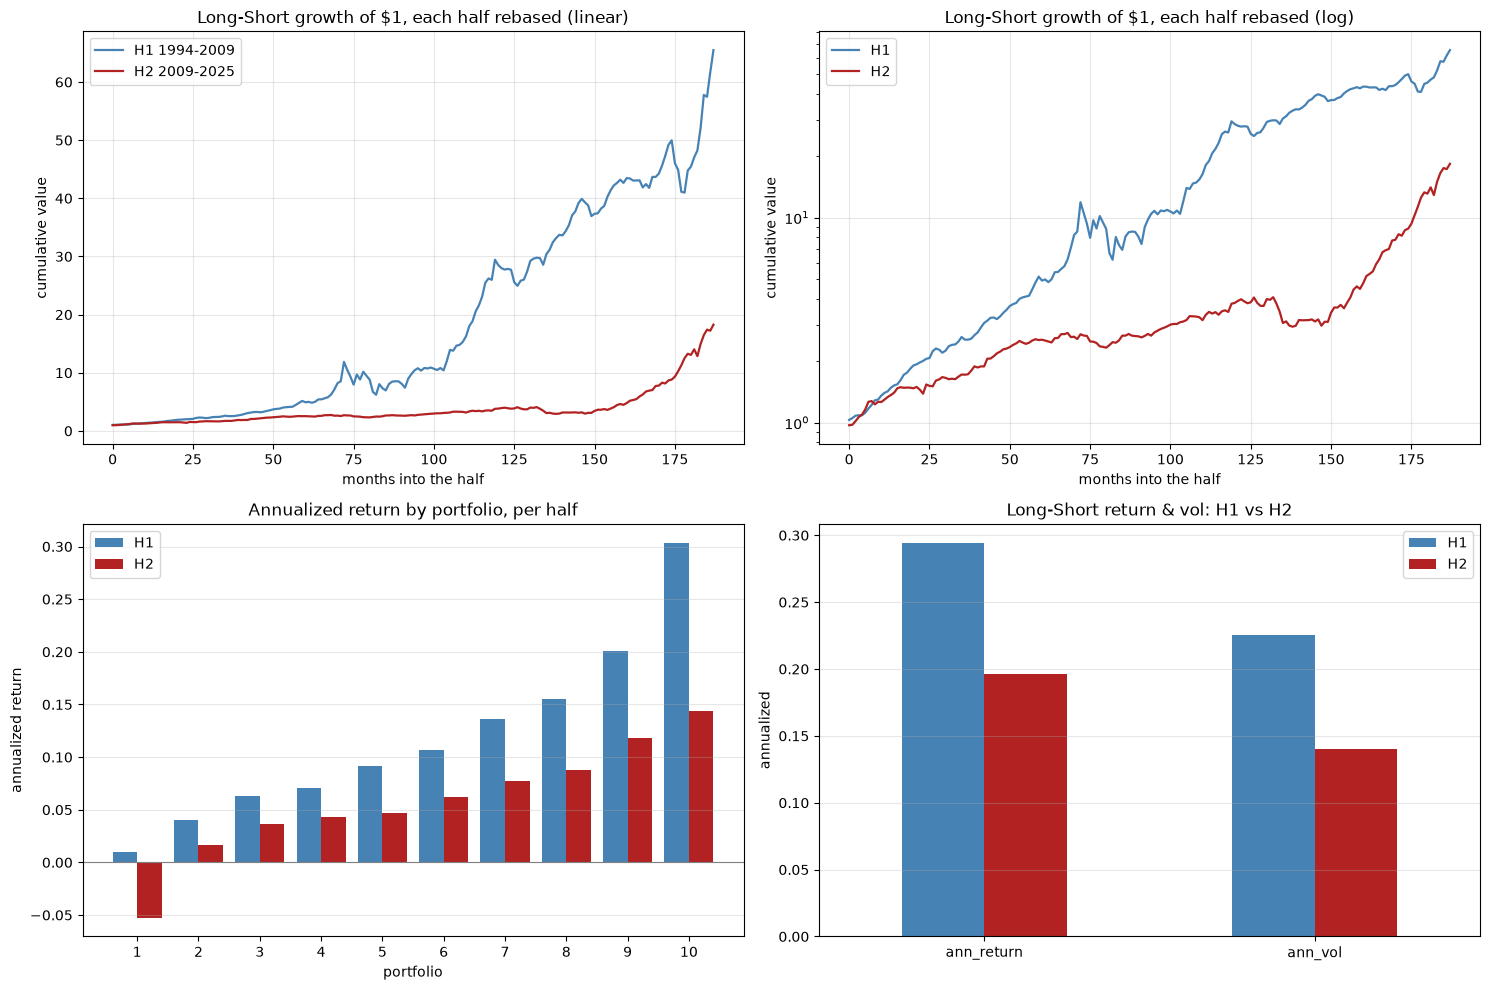

In [51]:
# ---- compare the two halves visually ---------------------------------------
# Each half's growth of $1 is REBASED to start at 1 at the start of that half,
# so the two eras are compared on equal footing (H2 doesn't inherit H1's level).
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. LS growth of $1, each half rebased to 1, linear
ax = axes[0, 0]
for h, lab, col in ((h1, f"H1 {h1.index.year.min()}-{h1.index.year.max()}", "steelblue"),
                    (h2, f"H2 {h2.index.year.min()}-{h2.index.year.max()}", "firebrick")):
    g = (1 + h["LS"]).cumprod()
    ax.plot(np.arange(len(g)), g.values, lw=1.6, color=col, label=lab)
ax.set_title("Long-Short growth of $1, each half rebased (linear)")
ax.set_xlabel("months into the half"); ax.set_ylabel("cumulative value")
ax.legend(); ax.grid(True, alpha=0.3)

# 2. same, log axis
ax = axes[0, 1]
for h, lab, col in ((h1, "H1", "steelblue"), (h2, "H2", "firebrick")):
    g = (1 + h["LS"]).cumprod()
    ax.plot(np.arange(len(g)), g.values, lw=1.6, color=col, label=lab)
ax.set_yscale("log")
ax.set_title("Long-Short growth of $1, each half rebased (log)")
ax.set_xlabel("months into the half"); ax.set_ylabel("cumulative value")
ax.legend(); ax.grid(True, alpha=0.3)

# 3. decile monotonicity in each half (does the P1->P10 rise survive both?)
ax = axes[1, 0]
cols = [f"P{i}" for i in range(1, N_PORT+1)]
w = 0.4
ax.bar(np.arange(N_PORT) - w/2, h1[cols].mean()*ANNUALIZE, w,
       color="steelblue", label="H1")
ax.bar(np.arange(N_PORT) + w/2, h2[cols].mean()*ANNUALIZE, w,
       color="firebrick", label="H2")
ax.axhline(0, color="grey", lw=0.8)
ax.set_title("Annualized return by portfolio, per half")
ax.set_xlabel("portfolio"); ax.set_ylabel("annualized return")
ax.set_xticks(range(N_PORT)); ax.set_xticklabels(range(1, N_PORT+1))
ax.legend(); ax.grid(True, alpha=0.3, axis="y")

# 4. annualized return + vol bars, H1 vs H2
ax = axes[1, 1]
metrics = pd.DataFrame({
    "H1": [h1["LS"].mean()*ANNUALIZE, h1["LS"].std()*np.sqrt(ANNUALIZE)],
    "H2": [h2["LS"].mean()*ANNUALIZE, h2["LS"].std()*np.sqrt(ANNUALIZE)],
}, index=["ann_return", "ann_vol"])
metrics.plot(kind="bar", ax=ax, color=["steelblue", "firebrick"])
ax.set_title("Long-Short return & vol: H1 vs H2")
ax.set_ylabel("annualized"); ax.set_xticklabels(metrics.index, rotation=0)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

### Long-only (top decile) — halves side by side

The tradable no-shorting version is **P10** held alone. Panels are separate (not overlaid) so each half is read on its own axis. P1 is shown too: comparing the two long-only legs reveals *where* the long-short spread comes from — if most of it is in P1 (the short leg), the strategy depends on shorting and P10 alone will look much weaker.

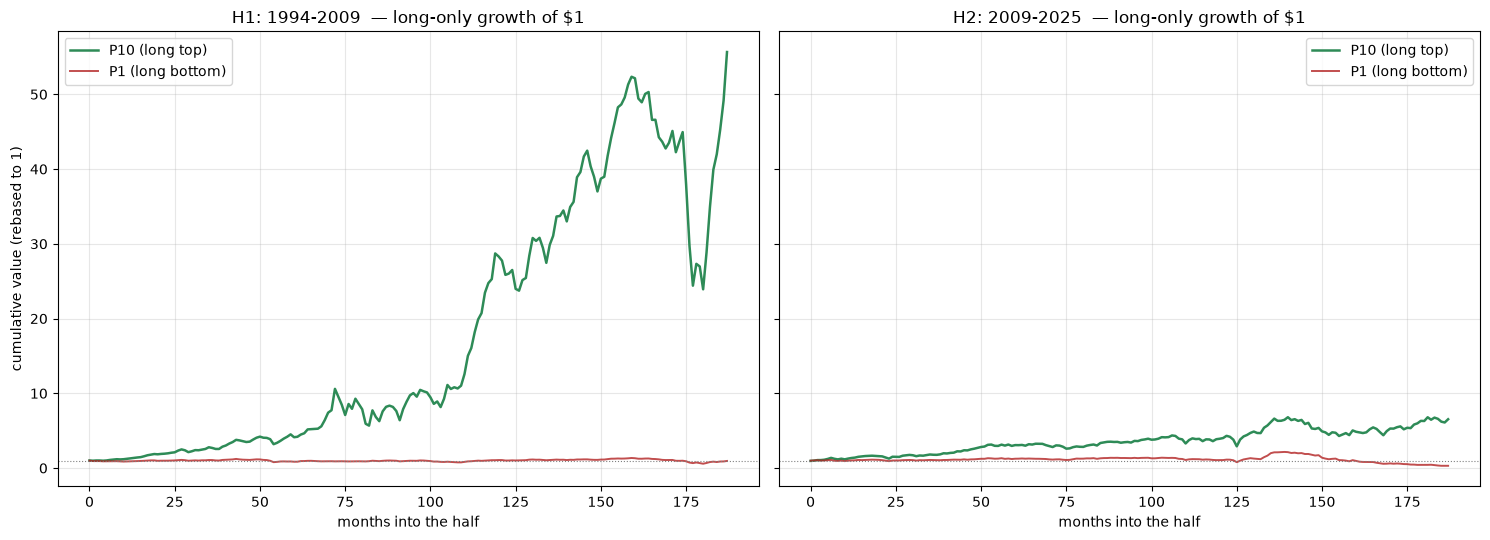

,P10 H1,P10 H2,P1 H1,P1 H2
months,188.0000,188.0000,188.0000,188.0000
ann_return,0.3038,0.1438,0.0099,-0.0526
ann_vol,0.3033,0.2187,0.1620,0.2151
sharpe,1.0016,0.6578,0.0611,-0.2443
hit_rate,0.6543,0.5638,0.5532,0.4894
max_drawdown,-0.5432,-0.3693,-0.5693,-0.8602
t_stat,3.9644,2.6036,0.2418,-0.9670
p_value,0.0001,0.0100,0.8092,0.3348


In [52]:
# ---- long-only P10 (and P1) growth of $1, halves in separate panels ---------
top, bot = f"P{N_PORT}", "P1"

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)
halves = [("H1", h1, f"{h1.index.year.min()}-{h1.index.year.max()}"),
          ("H2", h2, f"{h2.index.year.min()}-{h2.index.year.max()}")]

for ax, (tag, h, span) in zip(axes, halves):
    g_top = (1 + h[top]).cumprod()
    g_bot = (1 + h[bot]).cumprod()
    x = np.arange(len(h))                       # months into the half
    ax.plot(x, g_top.values, lw=1.8, color="seagreen",
            label=f"{top} (long top)")
    ax.plot(x, g_bot.values, lw=1.4, color="firebrick", alpha=0.8,
            label=f"{bot} (long bottom)")
    ax.axhline(1, color="grey", lw=0.8, ls=":")
    ax.set_title(f"{tag}: {span}  — long-only growth of $1")
    ax.set_xlabel("months into the half"); ax.grid(True, alpha=0.3)
    ax.legend()
axes[0].set_ylabel("cumulative value (rebased to 1)")
plt.tight_layout(); plt.show()

# ---- long-only stats table, both legs x both halves ------------------------
lo = pd.DataFrame({
    f"{top} H1": period_stats(h1[top]), f"{top} H2": period_stats(h2[top]),
    f"{bot} H1": period_stats(h1[bot]), f"{bot} H2": period_stats(h2[bot]),
})
lo.round(4)